# DEEP LEARNING: Segmentación de Imágenes mediante U-Net

En este apartado, abordamos el desarrollo y entrenamiento de un modelo de **Deep Learning** especializado en la segmentación semántica de imágenes. Siguiendo la metodología del ejemplo `code/DL/UNET`, implementaremos un flujo de trabajo completo que abarca desde el procesamiento de datos hasta la validación de resultados en tiempo real.

### **Objetivo del ejercicio**
El objetivo principal es construir y entrenar una red neuronal convolucional con arquitectura **U-Net** utilizando un conjunto de imágenes propio. El sistema debe ser capaz de aprender a identificar y aislar automáticamente regiones de interés (en este caso, rostros) a partir de máscaras generadas manualmente, transformando una tarea de etiquetado laboriosa en un proceso de inferencia automatizado y preciso.

### **Pasos del proceso**
1. **Etiquetado (`masker.py`)**: Creación del dataset mediante máscaras manuales.
2. **Determinación de ROI**: Visualización y validación de las regiones de interés seleccionadas.
3. **Dataset (`prepare.py`)**: Generación de recortes y aumento de datos para mejorar la generalización.
4. **Entrenamiento (`train.py`)**: Definición de la arquitectura U-Net y optimización de pesos mediante Adam y MSE.
5. **Comprobación (`check.py`)**: Validación visual del aprendizaje sobre muestras aleatorias del dataset.
6. **Inferencia (`rununet.py`)**: Aplicación del modelo final sobre imágenes completas y casos de prueba.
   
Comenzaremos importando las librerías necesarias;

In [1]:
import numpy as np
import cv2 as cv
import glob
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import glob

# Configuración de dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Entrenando en: {device}")

Entrenando en: cpu


## **Paso 1 y 2: Etiquetado con `masker.py` y determinación de ROI**

En esta fase inicial, establecemos la base del entrenamiento. 

* Utilizamos la herramienta interactiva `masker.py` para delimitar manualmente las regiones de interés (ROI) sobre nuestras imágenes originales.
* El script registra las coordenadas mediante eventos del ratón y genera una máscara binaria donde el color blanco representa el objeto a detectar y el negro el fondo.
* Estas máscaras se guardan automáticamente con el prefijo `mask_` al pulsar la tecla **ESC**.

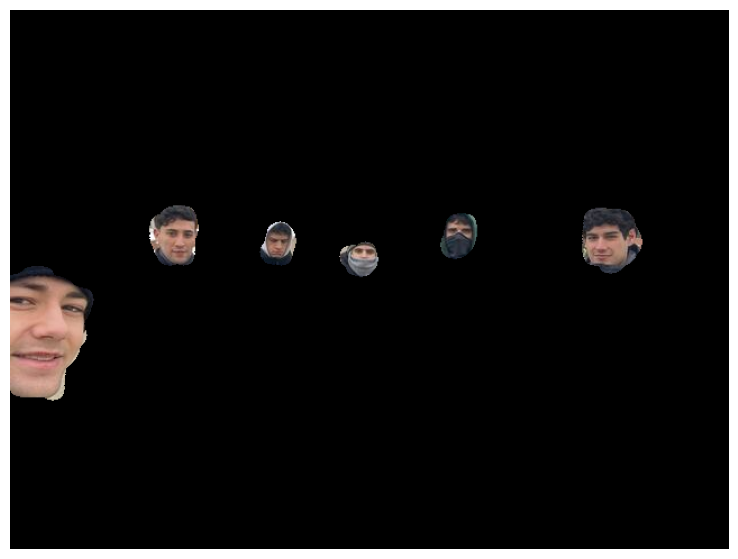

In [2]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

%matplotlib inline

img = cv.imread('caras_mias/imagen2.jpeg')
mask = cv.imread('caras_mias/mask_imagen2.jpeg')

if img is not None and mask is not None:
    res = np.where(mask > 128, img, 0)    
    plt.figure(figsize=(10,7))
    plt.imshow(cv.cvtColor(res, cv.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show() 

## **Paso 3: Preparación del Dataset y Aumento de Datos**

Para que una red neuronal profunda generalice correctamente, necesitamos un volumen considerable de ejemplos. Dado que el número de imágenes originales suele ser limitado, aplicamos técnicas de **Data Augmentation** a través del script `prepare.py`.

* **Generación de recortes:** El sistema extrae múltiples cuadros aleatorios de **128x128** píxeles centrados tanto en las zonas marcadas como en áreas de fondo.
* **Reflejado (Mirroring):** Se duplican los ejemplos invirtiendo horizontalmente las imágenes para aumentar la variabilidad del entrenamiento.
* **Empaquetado:** Todos los recortes generados se almacenan en un archivo comprimido `samples.npz` para optimizar la carga en memoria durante el entrenamiento.

Archivos encontrados: ['caras_mias/mask_imagen3.jpeg', 'caras_mias/mask_imagen4.jpeg', 'caras_mias/mask_imagen5.jpeg', 'caras_mias/mask_imagen2.jpeg', 'caras_mias/mask_imagen1.jpeg']
Formato final de X: (1040, 128, 128, 3)
Formato final de Y: (1040, 128, 128)


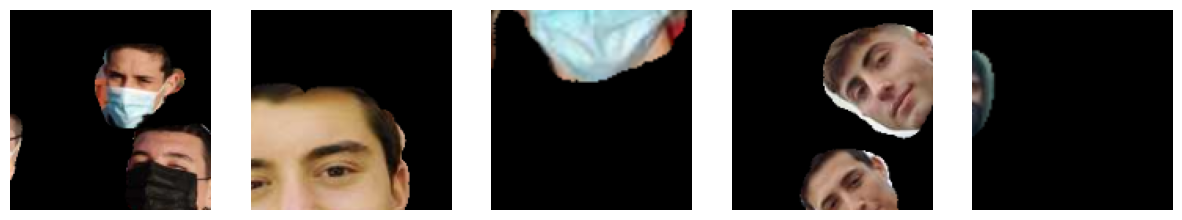

In [3]:
# Configura aquí tus carpetas y opciones
EXAMPLES_FOLDER = 'caras_mias'
SHOW_EXAMPLES = True            
MIRROR_EFFECT = True            

def see_masked(img, mask):
    return np.where(mask, img, 0)

# Buscamos las máscaras
filenames = glob.glob(os.path.join(EXAMPLES_FOLDER, "mask_*.*"))
print(f"Archivos encontrados: {filenames}")

# Cargamos el dataset original
dataset = []
for filename in filenames:
    img_path = filename.replace('mask_', '')
    img = cv.imread(img_path)
    mask = cv.imread(filename)
    
    if img is not None and mask is not None:
        dataset.append((
            cv.cvtColor(img, cv.COLOR_BGR2RGB),
            mask > 128
        ))

SZ     = 128
EXPAND = 20

def extract_region(img, pos, sz):
    H, W = img.shape[:2]
    x, y = pos
    r = sz // 2
    x = min(max(x, r), W - r)
    y = min(max(y, r), H - r)
    return img[y-r:y+r, x-r:x+r]

def expand(sample, N, size):
    source, mask = sample
    mask = (mask[:,:,0]*255).astype(np.uint8)
    
    def getSampleAt(x,y):
        size0 = size//2 + np.random.randint(0,size)
        src = extract_region(source,(x,y),size0)
        msk = extract_region(mask,(x,y),size0)
        return cv.resize(src,(size,size)), cv.resize(msk,(size,size))

    H, W = mask.shape
    S = min(H, W) / 10
    n, cc, st, cen = cv.connectedComponentsWithStats(mask)
    samples = []
    
    for x in range(1, n):
        xc, yc = int(cen[x][0]), int(cen[x][1])
        for _ in range(N):
            rx, ry = (np.random.randn(2) * S + (xc, yc)).astype(int)
            samples.append(getSampleAt(rx, ry))
            
    for _ in range(N):
        rx, ry = np.random.randint([0, 0], [W, H], 2)
        samples.append(getSampleAt(rx, ry))
    return samples

# Generamos el set de entrenamiento
training_set = []
for s in dataset:
    training_set += expand(s, EXPAND, SZ)
    if MIRROR_EFFECT:
        sm = (np.fliplr(s[0]), np.fliplr(s[1]))
        training_set += expand(sm, EXPAND, SZ)

ax = np.array([s[0] for s in training_set])
ay = np.array([s[1] for s in training_set])

print(f"Formato final de X: {ax.shape}")
print(f"Formato final de Y: {ay.shape}")

def show_example(s):
    img, mask = s
    r = (img/255) * (mask.reshape(*mask.shape, 1) / 255)
    return r

if SHOW_EXAMPLES:
    plt.figure(figsize=(15, 5))
    for i in range(5):
        k = np.random.randint(len(training_set))
        plt.subplot(1, 5, i+1)
        plt.imshow(show_example(training_set[k]))
        plt.axis('off')
    plt.show()

# Guardamos el archivo final
if not SHOW_EXAMPLES:
    np.savez('samples.npz', x=ax, y=ay)
    print("Archivo samples.npz guardado con éxito.")


# Paso 4: Entrenamiento del Modelo

En este apartado implementamos el proceso de aprendizaje de la red neuronal que se corresponde con `train.py`con 50 epocas. El código integra la arquitectura **U-Net** y el bucle de optimización para ajustar los pesos del modelo basándose en los recortes generados anteriormente.

* **Flexibilidad**: El script detecta si ya existe un modelo previo (`caras.torch`) para cargarlo y refinar el entrenamiento, o crea uno nuevo desde cero si es la primera ejecución.
* **Configuración**: Se utiliza el optimizador **Adam** ($lr=1e-4$) y la función de pérdida **MSE** para minimizar el error píxel a píxel.
* **Monitorización**: Al finalizar las épocas, se muestra una gráfica con la evolución de la pérdida (*Loss*) para validar la convergencia del sistema.

Entrenando en: cpu
Cargando modelo existente 'caras.torch' para refinar...
Iniciando 50 épocas...
Epoch 1/50, Loss: 1112.0798
Epoch 2/50, Loss: 540.2387
Epoch 3/50, Loss: 504.8533
Epoch 4/50, Loss: 489.6612
Epoch 5/50, Loss: 477.8970
Epoch 6/50, Loss: 472.0277
Epoch 7/50, Loss: 471.8592
Epoch 8/50, Loss: 472.5765
Epoch 9/50, Loss: 479.7261
Epoch 10/50, Loss: 466.4388
Epoch 11/50, Loss: 472.8440
Epoch 12/50, Loss: 464.1775
Epoch 13/50, Loss: 451.5462
Epoch 14/50, Loss: 456.5915
Epoch 15/50, Loss: 441.7269
Epoch 16/50, Loss: 470.1239
Epoch 17/50, Loss: 450.2992
Epoch 18/50, Loss: 426.3634
Epoch 19/50, Loss: 422.6103
Epoch 20/50, Loss: 425.5618
Epoch 21/50, Loss: 439.1575
Epoch 22/50, Loss: 422.5051
Epoch 23/50, Loss: 387.8262
Epoch 24/50, Loss: 395.5669
Epoch 25/50, Loss: 387.7245
Epoch 26/50, Loss: 379.3972
Epoch 27/50, Loss: 384.3666
Epoch 28/50, Loss: 390.7994
Epoch 29/50, Loss: 456.7963
Epoch 30/50, Loss: 387.5590
Epoch 31/50, Loss: 389.4814
Epoch 32/50, Loss: 359.1837
Epoch 33/50, L

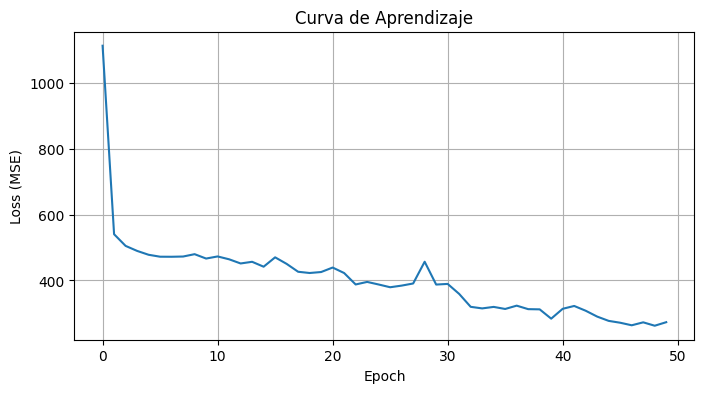

In [4]:
SAMPLES_FILE = 'samples.npz'  # El archivo generado en la celda anterior
MODEL_NAME   = 'caras.torch'  # Nombre para guardar/cargar el modelo
EPOCHS       = 50             # Número de épocas por ejecución
LEARNING_RATE = 1e-4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Entrenando en: {device}")

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU()
        )
        self.pool = nn.MaxPool2d(2, 2)
    def forward(self, x):
        c = self.conv(x)
        return c, self.pool(c)

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, skip_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU()
        )
    def forward(self, x, skip):
        return self.conv(torch.cat([self.up(x), skip], dim=1))

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.d1 = DownBlock(in_channels, 16); self.d2 = DownBlock(16, 32)
        self.d3 = DownBlock(32, 64); self.d4 = DownBlock(64, 128)
        self.bn = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
                                nn.Conv2d(256, 256, 3, padding=1), nn.ReLU())
        self.u1 = UpBlock(256, 128, 128); self.u2 = UpBlock(128, 64, 64)
        self.u3 = UpBlock(64, 32, 32); self.u4 = UpBlock(32, 16, 16)
        self.final = nn.Conv2d(16, out_channels, kernel_size=1)
    def forward(self, x):
        c1,p1 = self.d1(x); c2,p2 = self.d2(p1); c3,p3 = self.d3(p2); c4,p4 = self.d4(p3)
        return self.final(self.u4(self.u3(self.u2(self.u1(self.bn(p4), c4), c3), c2), c1))

if not os.path.exists(SAMPLES_FILE):
    raise FileNotFoundError(f"No se encuentra {SAMPLES_FILE}. Ejecuta la celda de preparación primero.")

samples = np.load(SAMPLES_FILE)
Xr, Y = samples['x'], samples['y']

dataset = TensorDataset(
    torch.from_numpy(Xr.astype(np.float32)[:,:,:,[1]].transpose(0,3,1,2)).to(device),
    torch.from_numpy(Y.astype(np.float32).reshape(-1, 1, 128, 128)).to(device)
)
dataloader = DataLoader(dataset, batch_size=20, shuffle=True)

if os.path.exists(MODEL_NAME):
    print(f"Cargando modelo existente '{MODEL_NAME}' para refinar...")
    model = torch.load(MODEL_NAME, map_location=device, weights_only=False)
else:
    print("Creando modelo nuevo desde cero...")
    model = UNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = torch.nn.MSELoss()

history = []
print(f"Iniciando {EPOCHS} épocas...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, labels in dataloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    
    epoch_loss = running_loss / len(dataset)
    history.append(epoch_loss)
    print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss:.4f}')

torch.save(model, MODEL_NAME)
print(f"Modelo guardado como '{MODEL_NAME}'")

plt.figure(figsize=(8, 4))
plt.plot(history)
plt.title("Curva de Aprendizaje")
plt.xlabel("Epoch"); plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

# Paso 5: Validación del Aprendizaje

En este apartado realizamos una comprobación visual del rendimiento del modelo utilizando una muestra aleatoria de los recortes de entrenamiento (`check.py`). 

* **Modo Inferencia**: El modelo se configura en modo evaluación (`eval()`) y se utiliza el contexto `no_grad()` para deshabilitar el cálculo de gradientes, optimizando así la velocidad de predicción.
* **Comparativa de Resultados**: El sistema genera una visualización triple que permite contrastar la imagen original de entrada, la máscara manual esperada (*Ground Truth*) y la estimación calculada por la red neuronal.
* **Propósito**: Esta validación es fundamental para observar si la red ha aprendido correctamente las formas de las zonas de interés o si las predicciones presentan ruido excesivo o falta de confianza.

In [5]:
SAMPLES_FILE = 'samples.npz'  
MODEL_NAME   = 'caras.torch'  
NUM_SAMPLES  = 13             # Cantidad de recortes a visualizar

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Entrenando en: {device}")

if not os.path.exists(SAMPLES_FILE) or not os.path.exists(MODEL_NAME):
    raise FileNotFoundError("Asegúrate de haber generado 'samples.npz' y entrenado 'caras.torch'.")

# Cargamos recortes y seleccionamos una muestra aleatoria
samples_data = np.load(SAMPLES_FILE)
Xr, Y = samples_data['x'], samples_data['y']
indices = np.random.choice(len(Xr), NUM_SAMPLES, replace=False)

# Cargamos el modelo 
model = torch.load(MODEL_NAME, map_location=device, weights_only=False)
model.eval() 

# Preparamos los recortes
xs = torch.from_numpy(Xr[indices].astype(np.float32)[:,:,:,[1]].transpose(0,3,1,2)).to(device)

with torch.no_grad():
    # La red predice la máscara
    ys = model(xs).cpu().numpy().reshape(-1, 128, 128)

# resultados
fig, axs = plt.subplots(3, 1, figsize=(15, 6))

# Fila 0: Imágenes originales (recortes)
axs[0].imshow(np.hstack(Xr[indices]))
axs[0].set_title("Input")
axs[0].set_axis_off()

# Fila 1: Máscaras manuales (lo que debería salir)
axs[1].imshow(np.hstack(Y[indices]), cmap='gray')
axs[1].set_title("Manual Masks")
axs[1].set_axis_off()

# Fila 2: Predicción de la UNet
axs[2].imshow(np.hstack(np.clip(ys, 0, 1)), cmap='gray')
axs[2].set_title("UNet Prediction")
axs[2].set_axis_off()

plt.tight_layout()
plt.show()

Entrenando en: cpu


AttributeError: Can't get attribute 'UNet' on <module '__main__'>

# Paso 6: Inferencia en Imágenes Completas

En este paso final, aplicamos el modelo entrenado sobre imágenes completas que no han sido troceadas previamente. El objetivo es validar la capacidad de la red para segmentar las zonas de interés en un escenario de uso real (`rununet.py`).

### **Aspectos Clave de la Implementación**
* **Compatibilidad Geométrica**: Para evitar errores en las conexiones de salto de la arquitectura U-Net, redimensionamos las imágenes de entrada para que sus dimensiones sean múltiplos de 16.
* **Normalización de Salida**: La red genera una predicción que procesamos para convertirla en una máscara binaria o probabilística. Al multiplicarla por la imagen original, logramos que solo las áreas detectadas permanezcan visibles, mientras el fondo se vuelve negro.
* **Inferencia**: El proceso se realiza bajo el contexto `torch.no_grad()` para optimizar el uso de memoria y velocidad, simulando el comportamiento que tendría el sistema en una ejecución en vivo con la cámara.

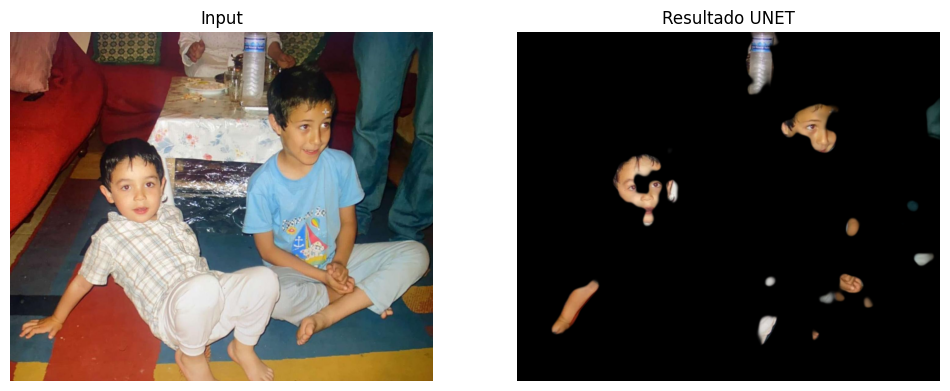

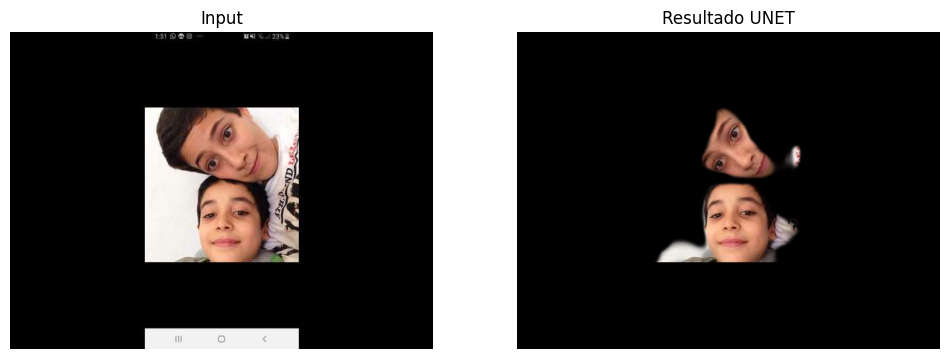

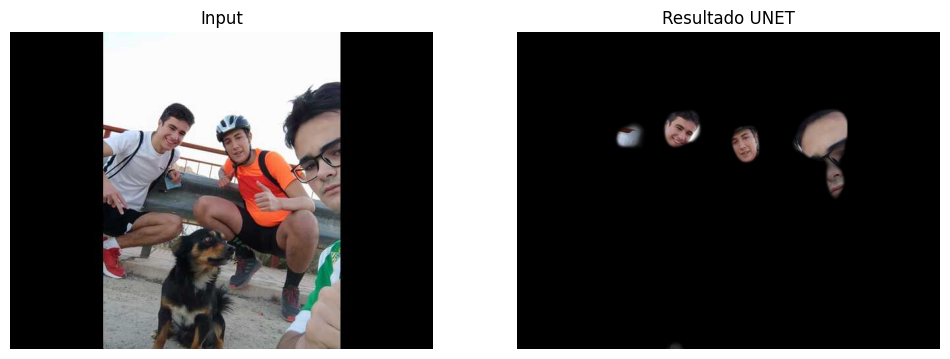

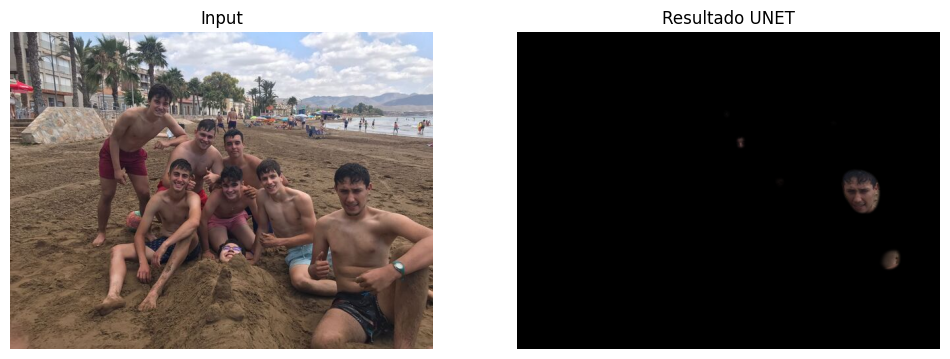

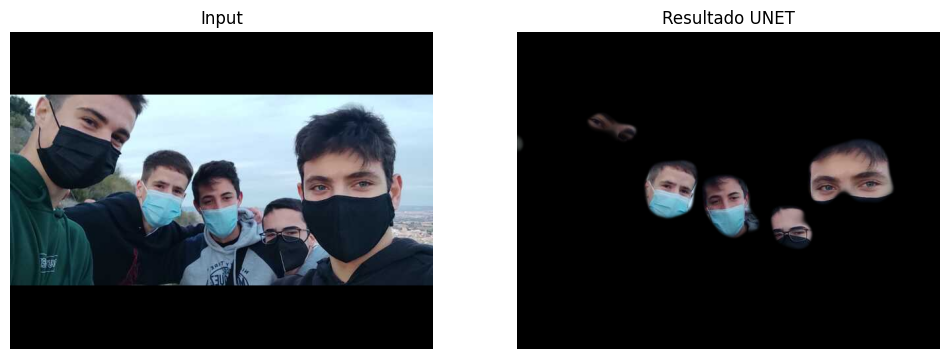

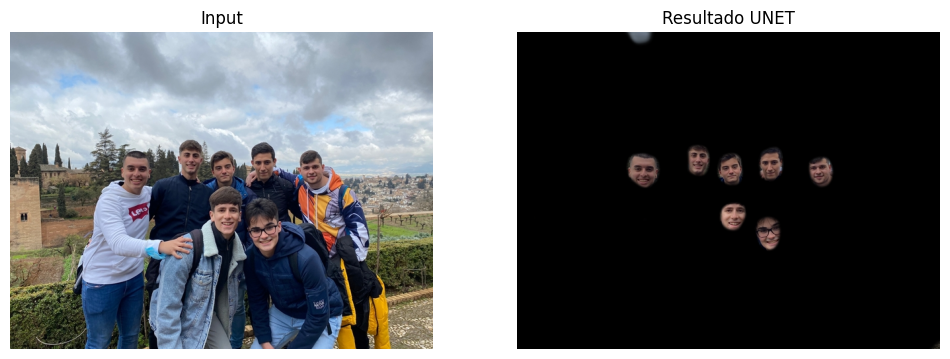

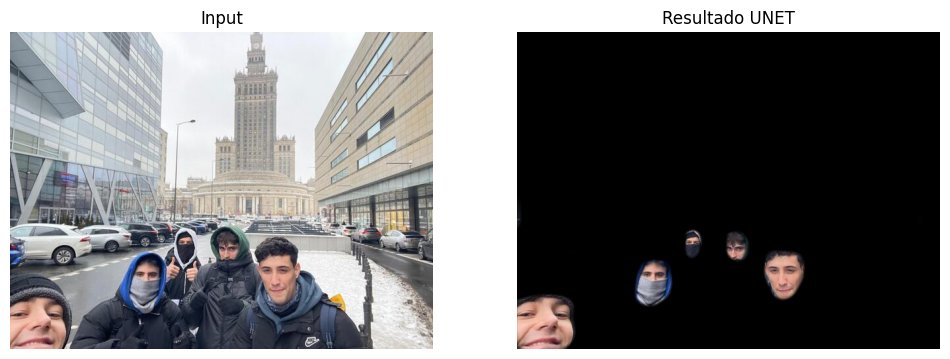

In [24]:
MODEL_NAME = 'caras.torch'
TEST_FOLDER = 'caras_mias_test'

# 1. Cargar el modelo exactamente como en rununet.py
model = torch.load(MODEL_NAME, map_location=device, weights_only=False)
model.eval()

test_images = glob.glob(os.path.join(TEST_FOLDER, "*.*"))

for img_path in test_images:
    orig = cv.imread(img_path)
    if orig is None: continue
        
    H, W = orig.shape[:2]
    nH, nW = (H // 16) * 16, (W // 16) * 16
    orig_res = cv.resize(orig, (nW, nH))
    
    # Preprocesamiento
    frame = cv.cvtColor(orig_res, cv.COLOR_BGR2GRAY)
    
    # Preparamos el tensor NCHW
    input_t = torch.from_numpy(frame.reshape(1, 1, nH, nW).astype(np.float32)).to(device)
    
    # 4. Inferencia
    with torch.no_grad():
        [r] = model(input_t)
        r_np = r[0].detach().cpu().numpy()
        
    r_uint8 = np.clip(r_np, 0, 255).astype(np.uint8)
    
    # normalizamos
    mask = np.expand_dims(r_uint8, 2) / 255.0
    
    # caras visibles
    mix = (orig_res * mask).astype(np.uint8)
    
    # 7. Visualización 
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(orig_res, cv.COLOR_BGR2RGB))
    plt.title("Input")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(mix, cv.COLOR_BGR2RGB))
    plt.title("Resultado UNET")
    plt.axis('off')
    
    plt.show()

# Conclusión

En general, el modelo presenta un rendimiento desigual dependiendo del contexto de las imágenes.

* **Entornos conocidos**: La detección es muy precisa en las imágenes de test que comparten el mismo escenario e iluminación que las de entrenamiento.
* **Entornos nuevos**: La precisión disminuye notablemente en lugares desconocidos para el modelo. Esto indica que la red ha aprendido patrones del fondo en lugar de rasgos faciales universales.
* **Solución**: Para lograr una mayor **generalización**, es necesario ampliar la diversidad del dataset con diferentes fondos y realizar un proceso de **refinamiento** con más épocas de entrenamiento.